# Dynamic Nelson–Siegel (DNS) Yield Curve Model

This notebook walks through a single-date cross-sectional Nelson–Siegel fit, which is the building block for the Dynamic Nelson–Siegel model.

The workflow is:

1. Load Treasury yield data
2. Select one date and corresponding maturity yields
3. Compute Nelson–Siegel loadings
4. Estimate the factors using OLS
5. Reconstruct the fitted curve
6. Plot:
   - actual vs fitted yields
   - contribution of level, slope, and curvature factors

In [97]:
# Imports
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt

In [98]:
# Fetch the data
df_yields = pd.read_csv("data/yields.csv", index_col=0, parse_dates=True).dropna()

# Format the data
df_yields.index = pd.to_datetime(df_yields.index, format="%Y-%m-%d")
df_yields = df_yields / 100.0

In [99]:
# Select one date for cross-sectional fitting
date = dt.datetime(2025, 9, 24)

# Maturities in years
tau = np.array([1/12, 3/12, 6/12, 1, 2, 3, 5, 7, 10, 20, 30], dtype=float)

# Observed yields for the selected date
yields = df_yields.loc[date].to_numpy()

print("Selected date:", date.date())
print("Observed yields:", yields)

Selected date: 2025-09-24
Observed yields: [0.0418 0.0402 0.0382 0.0363 0.0357 0.036  0.037  0.0391 0.0416 0.0473
 0.0476]


In [100]:
def ns_loadings(tau, lbd):
    """
    Compute Nelson-Siegel factor loadings.

    Parameters
    ----------
    tau : array-like
        Maturities in years.
    lbd : float
        Decay parameter lambda.

    Returns
    -------
    np.ndarray
        Matrix with columns:
        [level loading, slope loading, curvature loading]
    """
    tau = np.asarray(tau, dtype=float)

    level = np.ones_like(tau)
    slope = (1 - np.exp(-lbd * tau)) / (lbd * tau)
    curvature = slope - np.exp(-lbd * tau)

    return np.column_stack([level, slope, curvature])

# Fixed lambda as in Diebold and Li (2006)
lbd = 0.0609

# Loading matrix
L = ns_loadings(tau, lbd)

# Estimate beta via least squares
beta, residuals, rank, s = np.linalg.lstsq(L, yields, rcond=None)

beta_0, beta_1, beta_2 = beta

print(f"Estimated beta_0 (level):     {beta_0:.6f}")
print(f"Estimated beta_1 (slope):     {beta_1:.6f}")
print(f"Estimated beta_2 (curvature): {beta_2:.6f}")

Estimated beta_0 (level):     0.084972
Estimated beta_1 (slope):     -0.046855
Estimated beta_2 (curvature): -0.047399


In [101]:
# Fitted yield curve
y_fit = L @ beta

# Individual factor contributions
level_contrib = beta_0 * L[:, 0]
slope_contrib = beta_1 * L[:, 1]
curvature_contrib = beta_2 * L[:, 2]

# Check decomposition
reconstructed = level_contrib + slope_contrib + curvature_contrib
np.allclose(y_fit, reconstructed)

True

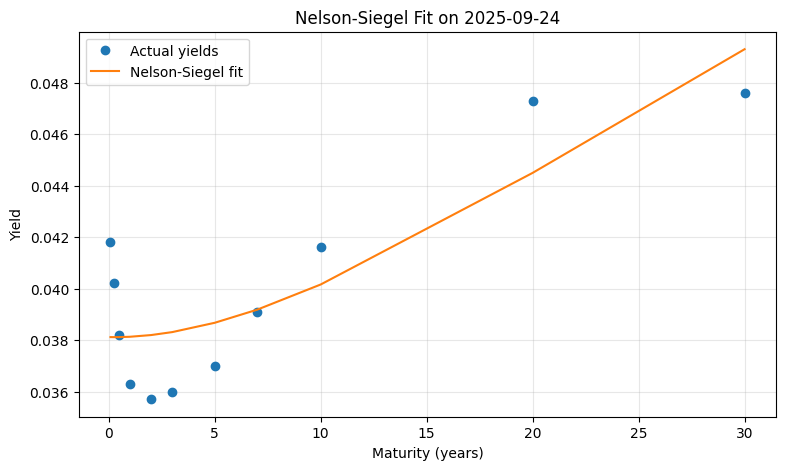

In [102]:
plt.figure(figsize=(9, 5))
plt.plot(tau, yields, 'o', label='Actual yields')
plt.plot(tau, y_fit, '-', label='Nelson-Siegel fit')

plt.xlabel("Maturity (years)")
plt.ylabel("Yield")
plt.title(f"Nelson-Siegel Fit on {date.date()}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

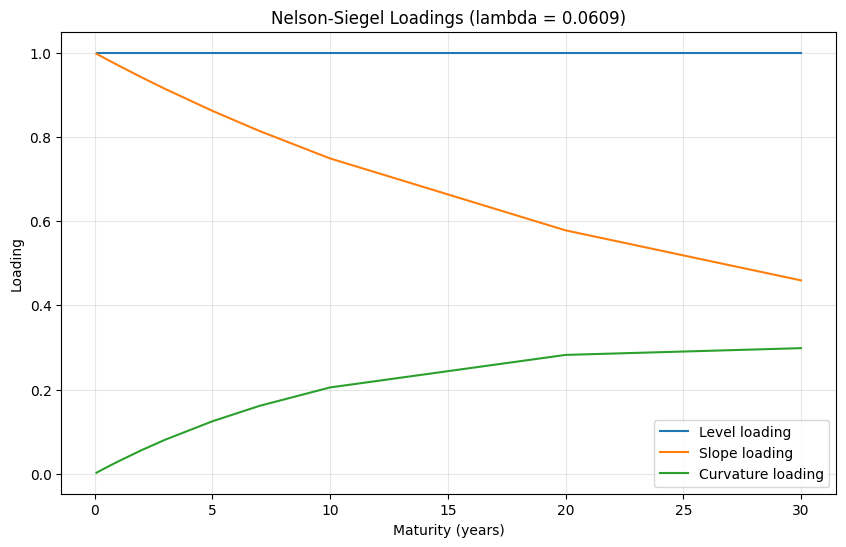

In [104]:
plt.figure(figsize=(10, 6))

plt.plot(tau, L[:, 0], label='Level loading')
plt.plot(tau, L[:, 1], label='Slope loading')
plt.plot(tau, L[:, 2], label='Curvature loading')

plt.xlabel("Maturity (years)")
plt.ylabel("Loading")
plt.title(f"Nelson-Siegel Loadings (lambda = {lbd})")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()